In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
file_path = "WHR2024.csv"
df = pd.read_csv(file_path)

In [4]:
# Display basic info and check for missing values
print("Initial Data Overview:")
print(df.info())
print("Missing Values:")
print(df.isnull().sum())


Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                143 non-null    object 
 1   Ladder score                                143 non-null    float64
 2   upperwhisker                                143 non-null    float64
 3   lowerwhisker                                143 non-null    float64
 4   Explained by: Log GDP per capita            140 non-null    float64
 5   Explained by: Social support                140 non-null    float64
 6   Explained by: Healthy life expectancy       140 non-null    float64
 7   Explained by: Freedom to make life choices  140 non-null    float64
 8   Explained by: Generosity                    140 non-null    float64
 9   Explained by: Perceptions of corruption     140 non-null    floa

In [7]:
# Identify numerical columns (excluding categorical ones like Country name)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols]

# Handling Missing Values
imputer = SimpleImputer(strategy="median")
df_numeric[:] = imputer.fit_transform(df_numeric)


<ipython-input-7-f3979bd69399>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric[:] = imputer.fit_transform(df_numeric)
<ipython-input-7-f3979bd69399>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric[:] = imputer.fit_transform(df_numeric)


In [8]:
# Outlier Detection and Removal using IQR
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_numeric = df_numeric[~((df_numeric < lower_bound) | (df_numeric > upper_bound)).any(axis=1)]

In [9]:
print("\nData after Outlier Removal:")
print(df_numeric.shape)


Data after Outlier Removal:
(120, 10)


In [10]:
# Restore categorical columns
df_cleaned = df.loc[df_numeric.index]

# Data Balancing using SMOTE (if applicable)
if 'Happiness Category' in df_cleaned.columns:
    X = df_cleaned.drop(columns=['Happiness Category'])
    y = df_cleaned['Happiness Category']
    smote = SMOTE()
    X_resampled, y_resampled = smote.fit_resample(X, y)
    df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
    df_balanced['Happiness Category'] = y_resampled
    print("\nData After Balancing:")
    print(df_balanced['Happiness Category'].value_counts())
else:
    df_balanced = df_cleaned

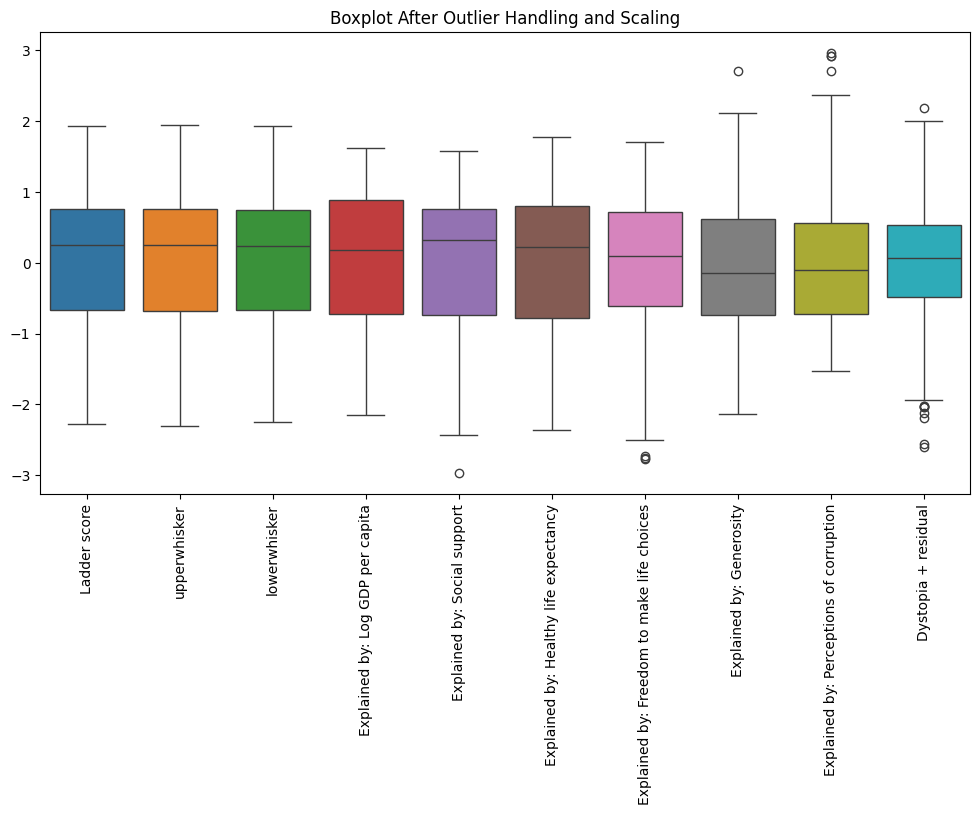

In [11]:
# Scaling Data
scaler = StandardScaler()
df_balanced[numeric_cols] = scaler.fit_transform(df_balanced[numeric_cols])

# Visualization of Processed Data
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_balanced[numeric_cols])
plt.title("Boxplot After Outlier Handling and Scaling")
plt.xticks(rotation=90)
plt.show()

In [12]:
# Save processed dataset
df_balanced.to_csv("WHR2024_processed.csv", index=False)
print("\nProcessed dataset saved as WHR2024_processed.csv")



Processed dataset saved as WHR2024_processed.csv
